In [36]:
import matplotlib.pyplot as plt
import numpy as np
import os

COL_AXIS = 1

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def step(x):
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            if x[i][j] > 0:
                x[i][j] = 1
            else:
                x[i][j] = 0
    return x

################################################

class Perceptron():

    def __init__(self, layers, activation = "sigmoid"):
        self.activation = activation
        self.layers = layers
        self.l = len(layers)
        a, b = 0.0, 0.5
        self.w = [np.random.normal(a,b,(layers[i]+1,layers[i+1])) for i in range(0,len(layers)-1)] 
        self.dw = [np.random.normal(a,b,(layers[i]+1,layers[i+1])) for i in range(0,len(layers)-1)]
        self.w.insert(0,[])
        self.errors = []

        
    def addBias(self, xh):
        return np.concatenate( ( xh, np.ones((1,1)) ) ,axis=COL_AXIS) #adding col for threshold 
        
      
    def subBias(self, v):
        return np.delete(v, v.shape[1]-1, axis=COL_AXIS)

    
    def activation_function(self, yb):
        if self.activation == "sigmoid":
            yb = sigmoid(yb)
        elif self.activation == "step":
            yb = step(yb)
        else:
            yb = np.tanh(yb)
        return yb
        
        
    def activate(self, xh):    #xh es un vector de dimension (#cols,)
        y  = [np.zeros(self.layers[i]).reshape((1,self.layers[i])) for i in range(0,len(self.layers))] # y debe tener tamaño #layers
        yb = xh.reshape((1,len(xh)))
        
        for k in range(1,self.l):
            y[k-1] = self.addBias(yb)
            yb = np.dot(y[k-1],self.w[k])
            yb = self.activation_function(yb)
            
        y[-1] = np.array(yb)
        return y


    def correction(self,nu,y,zh):
        e = zh.reshape((1,len(zh))) - y[-1]
        dw = [np.zeros((self.layers[i]+1,self.layers[i+1])) for i in range(0,len(self.layers)-1)]
        dw.insert(0,[])#dW con tamaño #layers
        d =  [0 for i in range(self.l)]
        ones = np.ones(y[-1].shape)
        dy = ones - np.square(y[-1]) #debe ser producto posicion a posicion
        d[self.l-1] = np.multiply(e,dy)

        for k in range(self.l-1, 0, -1): 
            #print("error=" + str(e))
            #print("y[k-1]=" + str(y[k-1]))
            dw[k] = nu * np.matmul(y[k-1].T, d[k])
            e = np.matmul(d[k],self.w[k].T)
            dy = np.ones(y[k-1].shape) - np.square(y[k-1])
            d[k-1] = self.subBias( np.multiply(e,dy) )
        return dw
        
        
    def predict(self, x):
        return self.activate(x)[-1]
    
    
    def train(self, x, z, epochs=4000, nu=0.001, epsilon = 0.01):
        p = x.shape[0]
        t=1
        out_modulus=epochs/8
        err = []
        e=1.0
        while t < epochs and e > epsilon:
            e = 0
            for h in range(p):
                y = self.activate(x[h])
                dw = self.correction(nu,y,z[h])
                self.w = [a + b for a, b in zip(self.w, dw)]
                e += np.linalg.norm(y[-1]-z[h].reshape((1,len(z[h]))))
            err.append(e)
            t+=1
            if t%out_modulus==0:
                print( t, e)
        return err

250 1.3972510407328838
500 1.5874680010110385
750 1.851354771329587
1000 2.2737016389073057
1250 2.945296975958002
1500 3.9759909608254347
1750 5.482340560810831
2000 7.5878025540623515


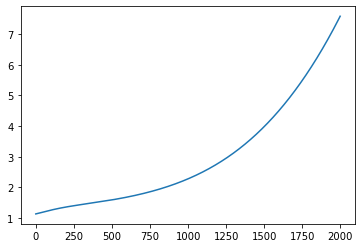

In [29]:
# n = 2 (input size) 
# m = 3 (output size) 
# p = 8 (#examples)  
x = np.array([[1,1], [1,-1],[-1,1],[-1,-1],[1,1], [1,-1],[-1,1],[-1,-1]]) 
z = np.array([[1, 0, 0, 0,1, 0, 0, 0],[1, 1, 1, 0,1, 1, 1, 0],[0, 1, 1, 1,0, 1, 1, 1]]).T 

s = np.array([2,5,5,5,5,3]) #Dos capas ocultas   
#w deberia ser nxm, o sea, 2x3 
p = Perceptron(s)  
err = p.train(x, z, epochs=2000, nu=0.001)  
plt.plot(err)  
#for i in range(len(x)): 
#print(str(p.predict(x[i])) + " =? " + str(z[i][0]) + str(z[i][1




5000 2.5694021337460504
10000 2.479439133143644
15000 2.2505025943212433
20000 2.0111948752761295
25000 1.7245760925051525
30000 1.612803003469201
35000 1.6070531028174155
40000 1.529394445920485
[[0.66364422 0.2148175 ]]


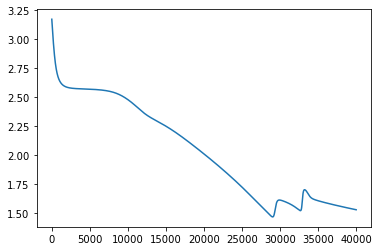

In [42]:
# n = 2 (input size)
# m = 2 (output size)
# p = 4 (#examples)
# L = 3 (#layers)

x = np.array([[1,1], [1,-1],[-1,1],[-1,-1]])
z = np.array([[1, 0], [0, 1], [0, 1], [0, 0]])
s = np.array([2,3,3,2])


#w debe ser una lista de tamaño 3
p = Perceptron(s)

err = p.train(x, z, epochs=40000, nu= 0.001)

plt.plot(err)
#print(err)
#for i in range(len(x)):
#        print(str(p.predict(x[i])) + " =? " + str(z[i][0]) + str(z[i][1]) + str(z[i][2]))

ex = np.ones((2,))
print(p.predict(ex))